-------------------------------------------------------------------------------------------
#         AI UniPod  
####      Prepared by Dr. Fantahun Bogale for AI Training for Government ICT Professionals   
####      Hawasa, Ethiopia                                                                   
####      December, 2025                                                                     
-------------------------------------------------------------------------------------------

# Demo: The AI/ML Pipeline Using Classical Machine Learning Algorithms 

In [20]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_curve, auc, roc_auc_score,
                             precision_recall_curve, f1_score)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['font.size'] = 12

# For reproducibility
np.random.seed(42)

# 1. Define the Problem 
### Problem Definition
Given four numerical features—sepal length, sepal width, petal length, and petal width—the objective is to predict the iris species (setosa, versicolor, or virginica). The dataset contains 150 samples across three classes.
### Input (Features)
Each data instance contains four numerical features:
1. Sepal length (cm)
2. Sepal width (cm)
3. Petal length (cm)
4. Petal width (cm)
### Output (Target Variable)
The goal is to classify each flower into one of three species:
1. Iris setosa
2. Iris versicolor
3. Iris virginica

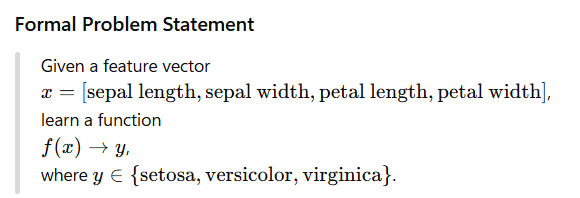

# 2. Data Aqcuisition 
### Data is already Prepared 
1. Download the data from publicly available files: https://www.kaggle.com/datasets/saurabh00007/iriscsv
2. Use Imbeded Data : the Iris dataset is bundled inside scikit-learn

# 3. Load Dataset

In [42]:
# Load the iris dataset
iris = load_iris()

#df = read_csv(path)


print("Dataset loaded successfully!")
print("\n" + "="*50)
print("IRIS DATASET OVERVIEW")
print("="*50)

# Display dataset information
print(f"Target names: {iris.target_names}")
print(f"Feature names: {iris.feature_names}")

print(f"Number of features: {iris.data.shape[1]}")
print(f"Number of classes: {len(np.unique(iris.target))}")


Dataset loaded successfully!

IRIS DATASET OVERVIEW
Target names: ['setosa' 'versicolor' 'virginica']
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Number of features: 4
Number of classes: 3


## 4. Exploratory Data Analysis (EDA)
### 4.1 Dataset Structure Overview

In [43]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [44]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

In [46]:
# Create a DataFrame for easier manipulation
df_aug = pd.DataFrame(iris.data, columns=iris.feature_names)
df_aug['species'] = iris.target
df_aug['species_name'] = df_aug['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

In [47]:
df_aug.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species', 'species_name'],
      dtype='object')

In [48]:
# Number of Examples
df_aug.shape

(150, 6)

In [49]:
df.shape

(150, 4)

In [57]:
# Display first few rows
df_aug.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [56]:
df_aug.tail()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [10]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

print("\n1. DATASET STRUCTURE")
print("-"*40)
print(f"Dataset shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values in each column:")
print(df.isnull().sum())

EXPLORATORY DATA ANALYSIS (EDA)

1. DATASET STRUCTURE
----------------------------------------
Dataset shape: (150, 6)

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int32
species_name          object
dtype: object

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


### 4.2 Statistical Summary

In [11]:
print("\n\n2. STATISTICAL SUMMARY")
print("-"*40)
display(df.describe())



2. STATISTICAL SUMMARY
----------------------------------------


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### 4.3 Class Distribution

In [12]:
print("\n3. CLASS DISTRIBUTION")
print("-"*40)
class_dist = df['species_name'].value_counts()
print(class_dist)


3. CLASS DISTRIBUTION
----------------------------------------
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


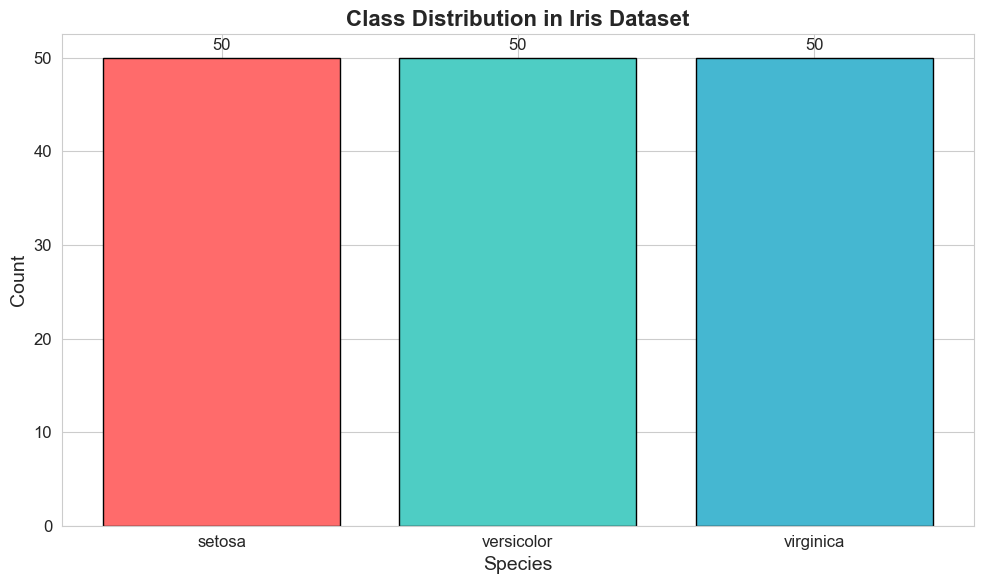

In [13]:
# Visualize class distribution
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(class_dist.index, class_dist.values, color=colors, edgecolor='black')
plt.title('Class Distribution in Iris Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Species', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

### 4.4 Feature Distributions and Relationships 

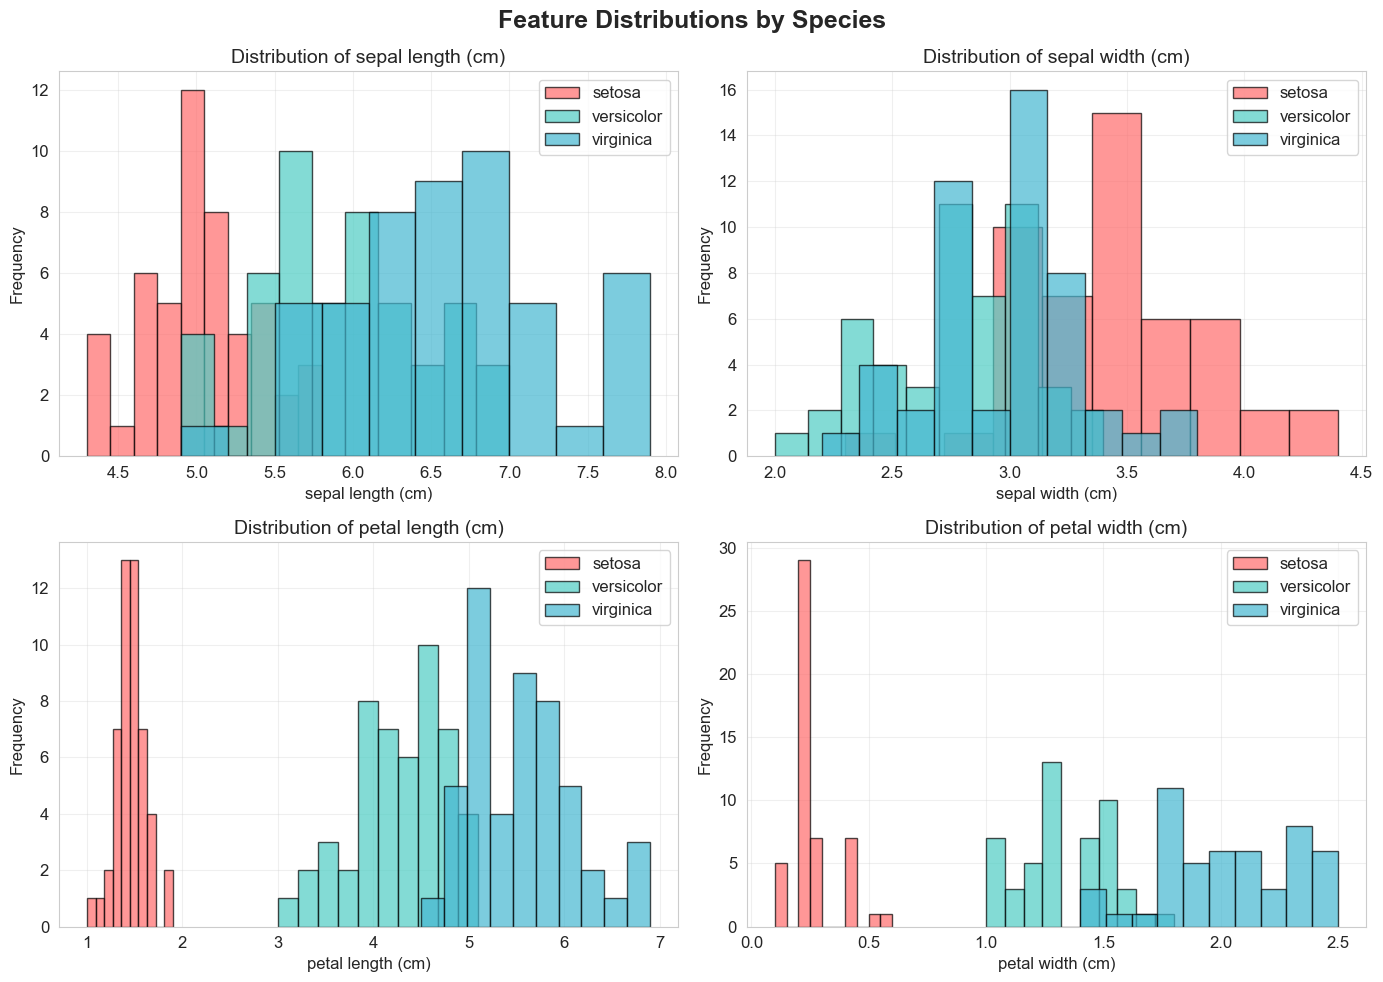

In [14]:
# Create subplots for feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions by Species', fontsize=18, fontweight='bold')

features = iris.feature_names
species = iris.target_names
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, feature in enumerate(features):
    ax = axes[idx//2, idx%2]
    for i, specie in enumerate(species):
        ax.hist(df[df['species_name'] == specie][feature], 
                alpha=0.7, label=specie, color=colors[i], edgecolor='black')
    ax.set_title(f'Distribution of {feature}', fontsize=14)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5 Correlation Analysis

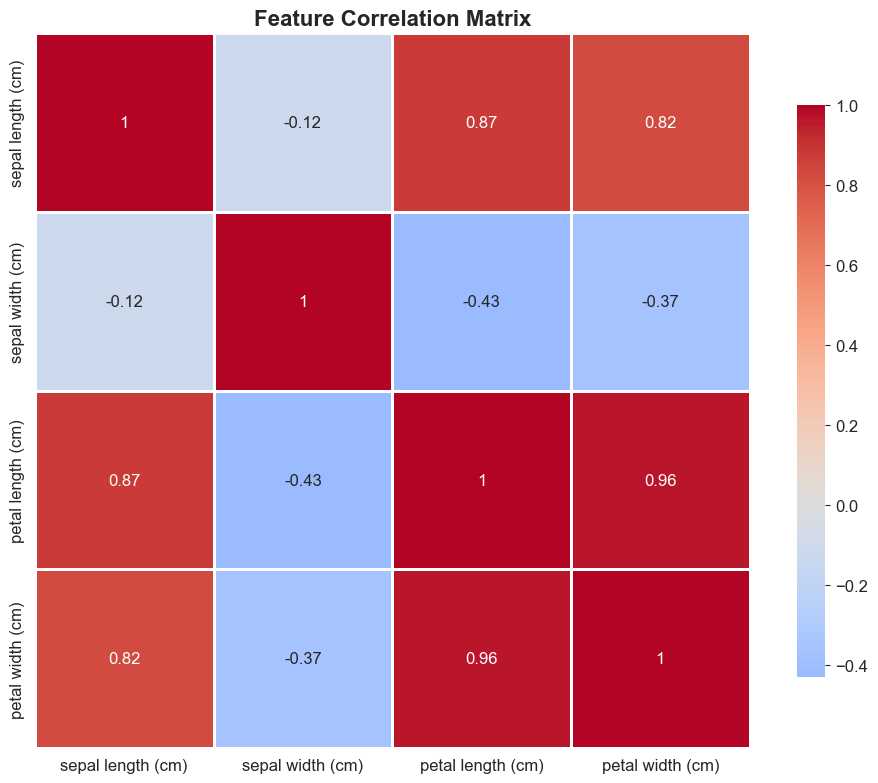


4. FEATURE RELATIONSHIPS (Pairplot)
----------------------------------------


<Figure size 1200x1000 with 0 Axes>

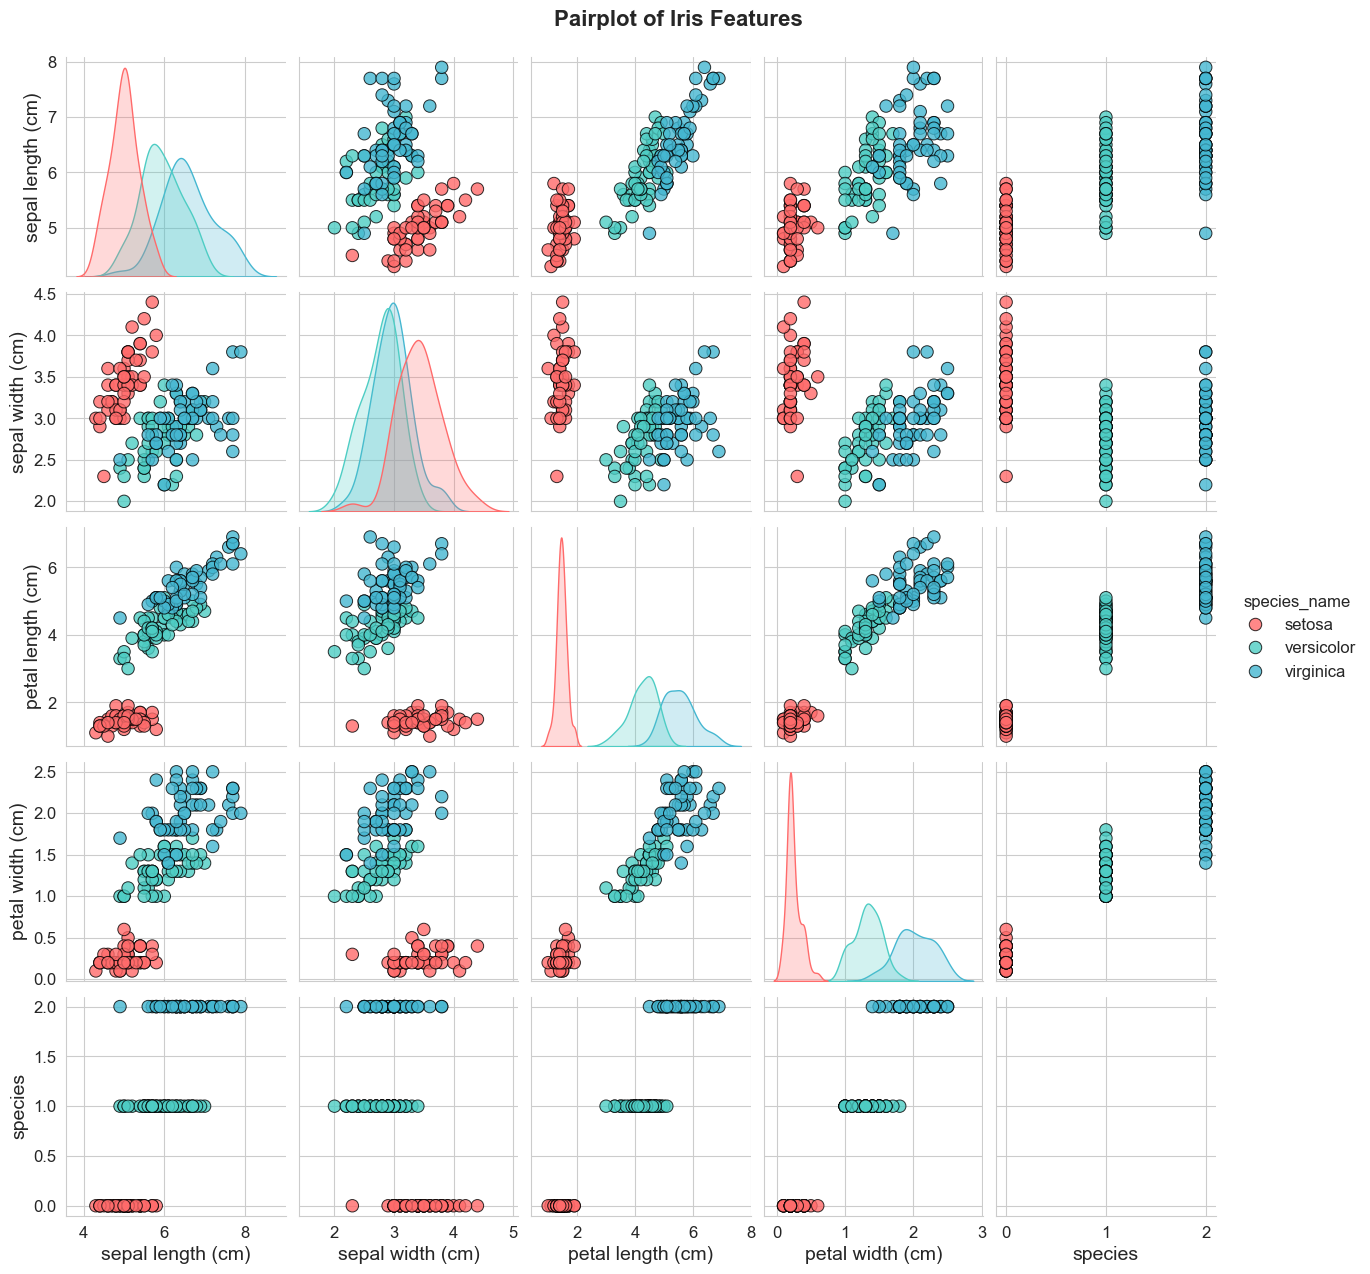

In [15]:
# Compute correlation matrix
correlation_matrix = df[iris.feature_names].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Pairplot for feature relationships
print("\n4. FEATURE RELATIONSHIPS (Pairplot)")
print("-"*40)
plt.figure(figsize=(12, 10))
sns.pairplot(df, hue='species_name', palette=colors, diag_kind='kde', 
             plot_kws={'alpha': 0.8, 's': 80, 'edgecolor': 'black'})
plt.suptitle('Pairplot of Iris Features', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### 4.6 Box Plots for Feature Analysis

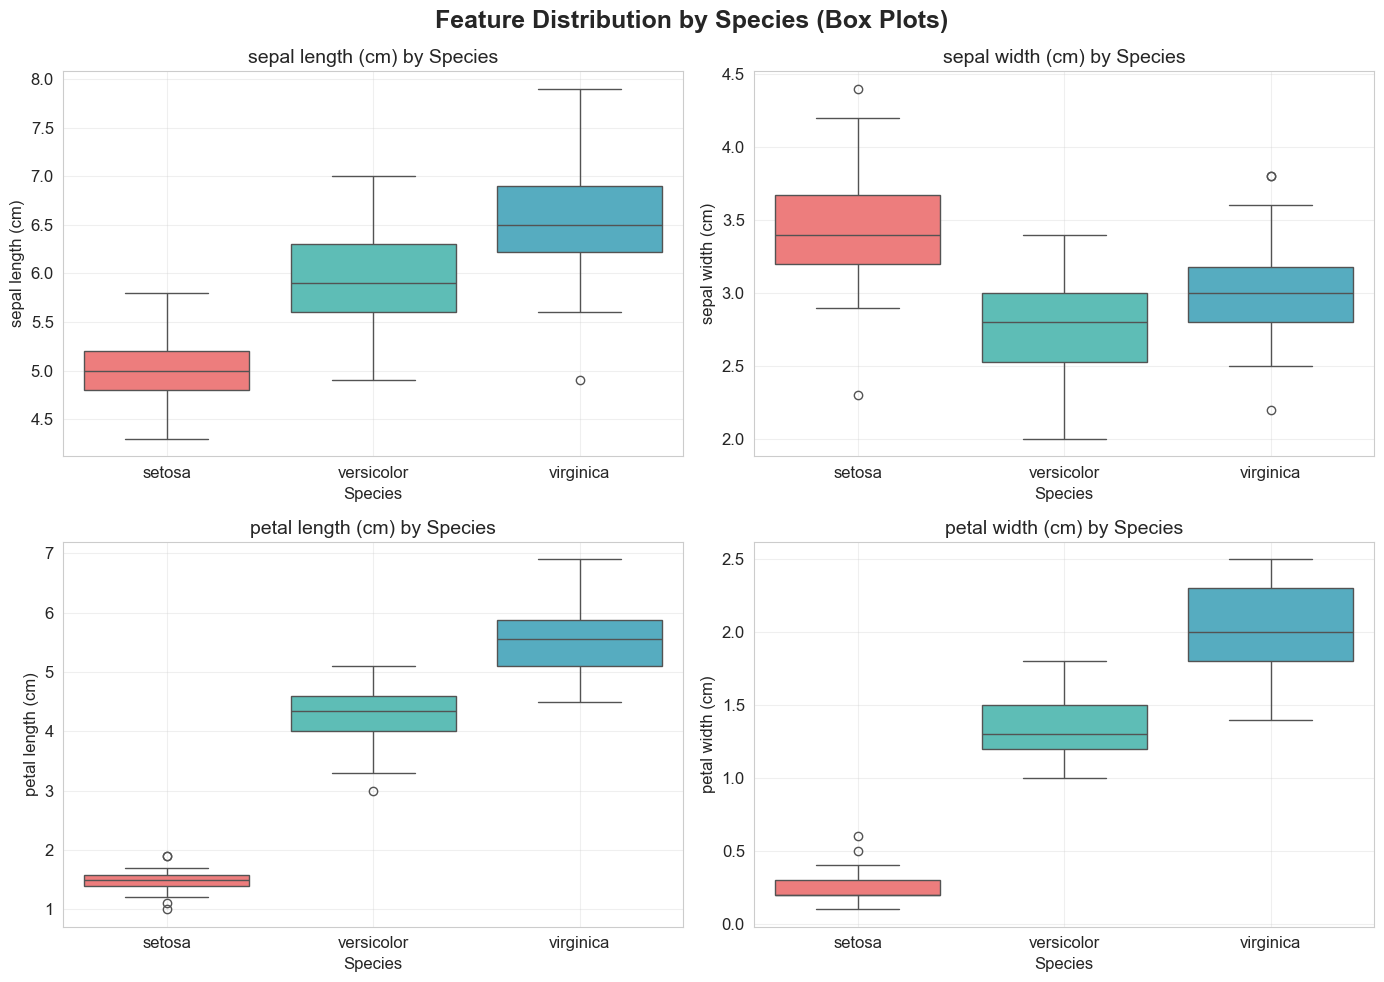

In [16]:
# Create box plots for each feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distribution by Species (Box Plots)', fontsize=18, fontweight='bold')

for idx, feature in enumerate(features):
    ax = axes[idx//2, idx%2]
    sns.boxplot(x='species_name', y=feature, data=df, palette=colors, ax=ax)
    ax.set_title(f'{feature} by Species', fontsize=14)
    ax.set_xlabel('Species', fontsize=12)
    ax.set_ylabel(feature, fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Data Preprocessing

In [17]:
print("="*60)
print("DATA PREPROCESSING")
print("="*60)

# Separate features and target
X = df[iris.feature_names]
y = df['species']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

DATA PREPROCESSING
Features shape: (150, 4)
Target shape: (150,)


In [18]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 120 samples
Testing set size: 30 samples


In [19]:
# Check class distribution in train and test sets
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

print("\nClass distribution in training set:")
for i, count in enumerate(train_dist):
    print(f"  Class {iris.target_names[i]}: {count} samples ({count/len(y_train)*100:.1f}%)")

print("\nClass distribution in testing set:")
for i, count in enumerate(test_dist):
    print(f"  Class {iris.target_names[i]}: {count} samples ({count/len(y_test)*100:.1f}%)")


Class distribution in training set:
  Class setosa: 40 samples (33.3%)
  Class versicolor: 40 samples (33.3%)
  Class virginica: 40 samples (33.3%)

Class distribution in testing set:
  Class setosa: 10 samples (33.3%)
  Class versicolor: 10 samples (33.3%)
  Class virginica: 10 samples (33.3%)


In [20]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures have been standardized (mean=0, std=1)")



Features have been standardized (mean=0, std=1)


# 6. Algorithm Selection, Model Training and Evaluation
#### We will compare these five classical Machine Learning algorithms. 
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine
5. K-Nearest Neighbors

In [21]:
print("="*60)
print("MODEL TRAINING AND EVALUATION")
print("="*60)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=iris.target_names, output_dict=True)
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'classification_report': report,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision (weighted avg): {report['weighted avg']['precision']:.4f}")
    print(f"  Recall (weighted avg): {report['weighted avg']['recall']:.4f}")
    print(f"  F1-Score (weighted avg): {report['weighted avg']['f1-score']:.4f}")



MODEL TRAINING AND EVALUATION

Training Logistic Regression...
  Accuracy: 0.9333
  Precision (weighted avg): 0.9333
  Recall (weighted avg): 0.9333
  F1-Score (weighted avg): 0.9333

Training Decision Tree...
  Accuracy: 0.9333
  Precision (weighted avg): 0.9333
  Recall (weighted avg): 0.9333
  F1-Score (weighted avg): 0.9333

Training Random Forest...
  Accuracy: 0.9000
  Precision (weighted avg): 0.9024
  Recall (weighted avg): 0.9000
  F1-Score (weighted avg): 0.8997

Training Support Vector Machine...
  Accuracy: 0.9667
  Precision (weighted avg): 0.9697
  Recall (weighted avg): 0.9667
  F1-Score (weighted avg): 0.9666

Training K-Nearest Neighbors...
  Accuracy: 0.9333
  Precision (weighted avg): 0.9444
  Recall (weighted avg): 0.9333
  F1-Score (weighted avg): 0.9327


In [22]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['classification_report']['weighted avg']['precision'] for m in results.keys()],
    'Recall': [results[m]['classification_report']['weighted avg']['recall'] for m in results.keys()],
    'F1-Score': [results[m]['classification_report']['weighted avg']['f1-score'] for m in results.keys()]
}).sort_values('Accuracy', ascending=False)

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
display(comparison_df)


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
3,Support Vector Machine,0.966667,0.969697,0.966667,0.966583
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,Decision Tree,0.933333,0.933333,0.933333,0.933333
4,K-Nearest Neighbors,0.933333,0.944444,0.933333,0.932660
2,Random Forest,0.900000,0.902357,0.900000,0.899749


### 6.1 Visualize Model Performance

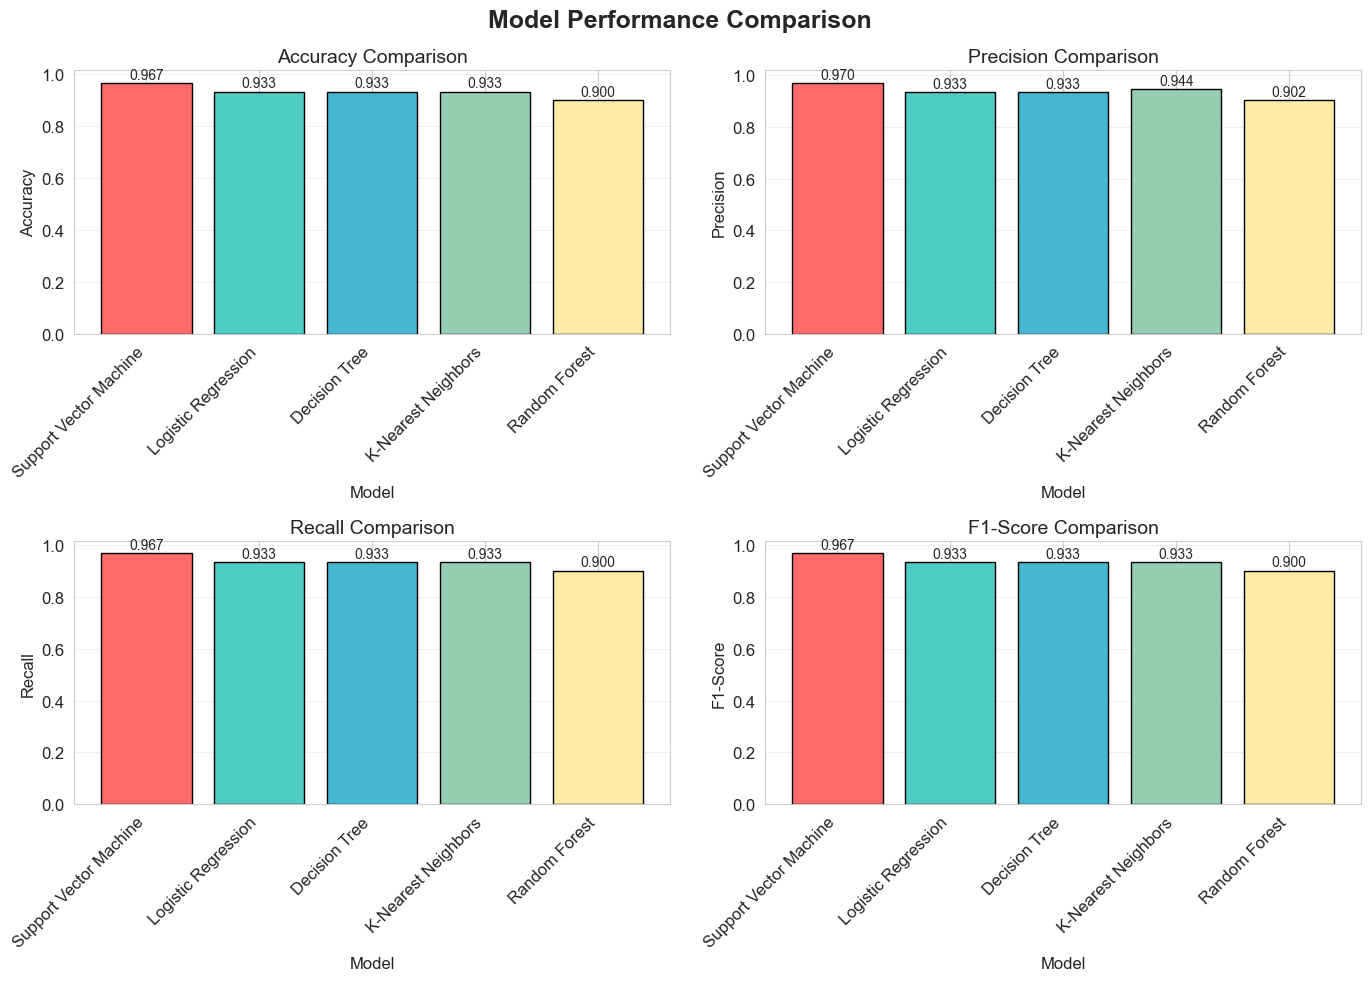

In [26]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_models = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for idx, metric in enumerate(metrics):
    ax = axes[idx//2, idx%2]
    x_pos = np.arange(len(comparison_df['Model']))
    bars = ax.bar(x_pos, comparison_df[metric], color=colors_models, edgecolor='black')
    ax.set_title(f'{metric} Comparison', fontsize=14)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 6.2 Confusion Matrices for All Models

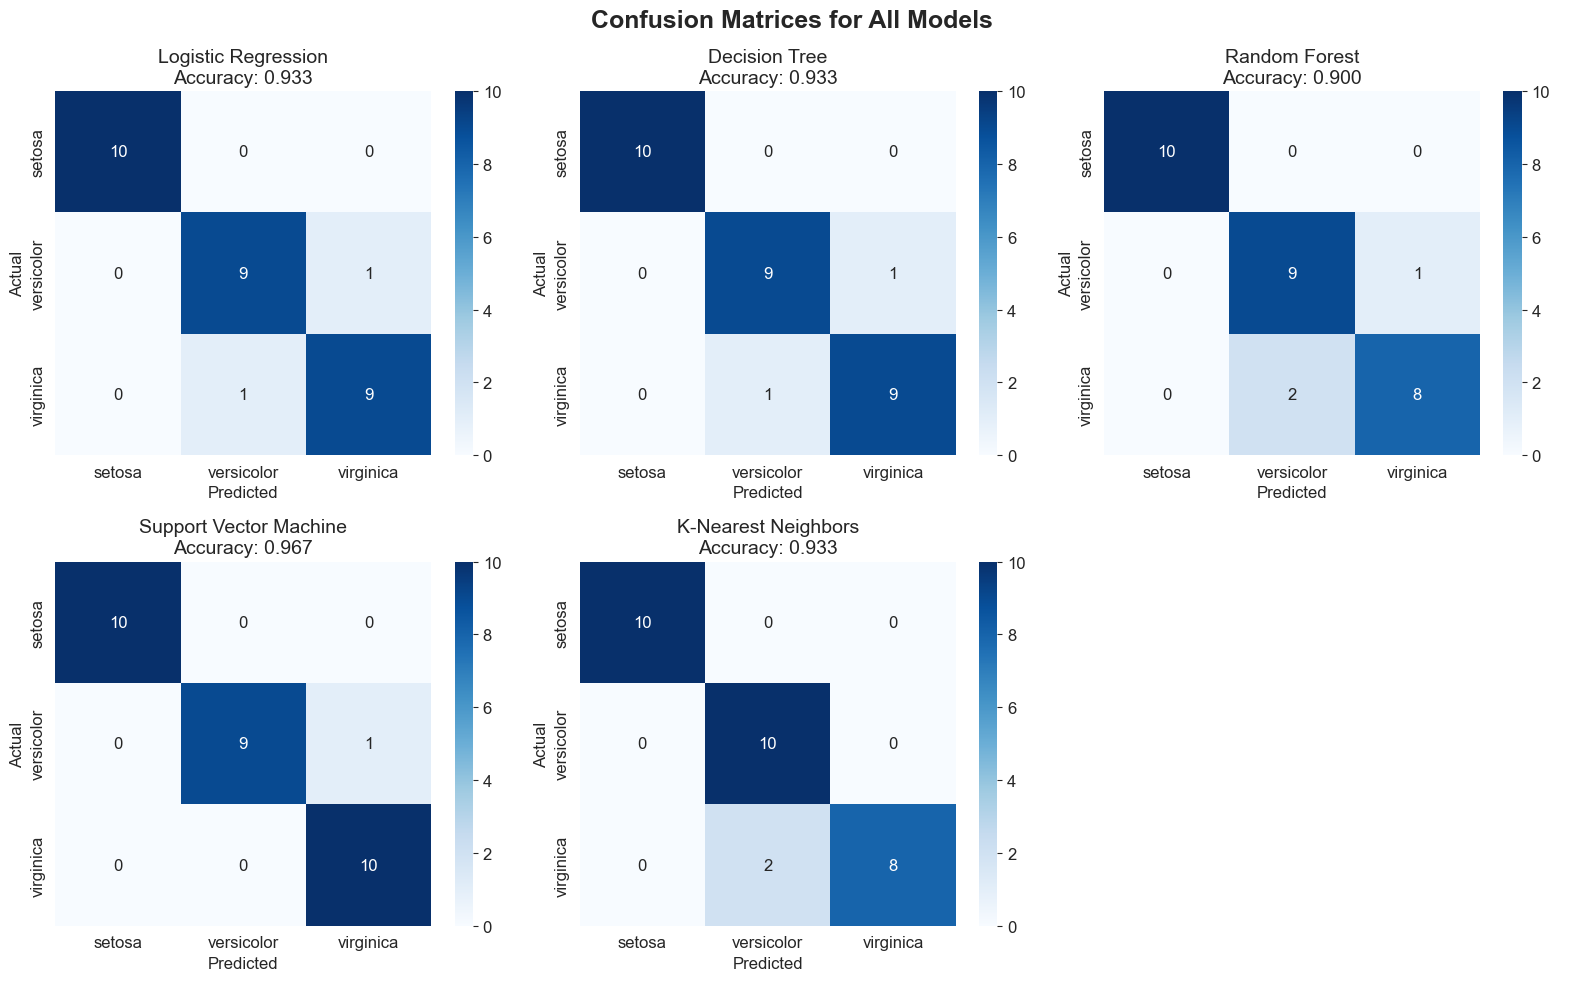

In [30]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flat
fig.suptitle('Confusion Matrices for All Models', fontsize=18, fontweight='bold')

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, result['y_pred'])
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=iris.target_names, 
                yticklabels=iris.target_names, ax=ax)
    
    ax.set_title(f'{name}\nAccuracy: {result["accuracy"]:.3f}', fontsize=14)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

# Hide empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()




### 6.3 Training Process Visualization


Visualizing Random Forest training process...


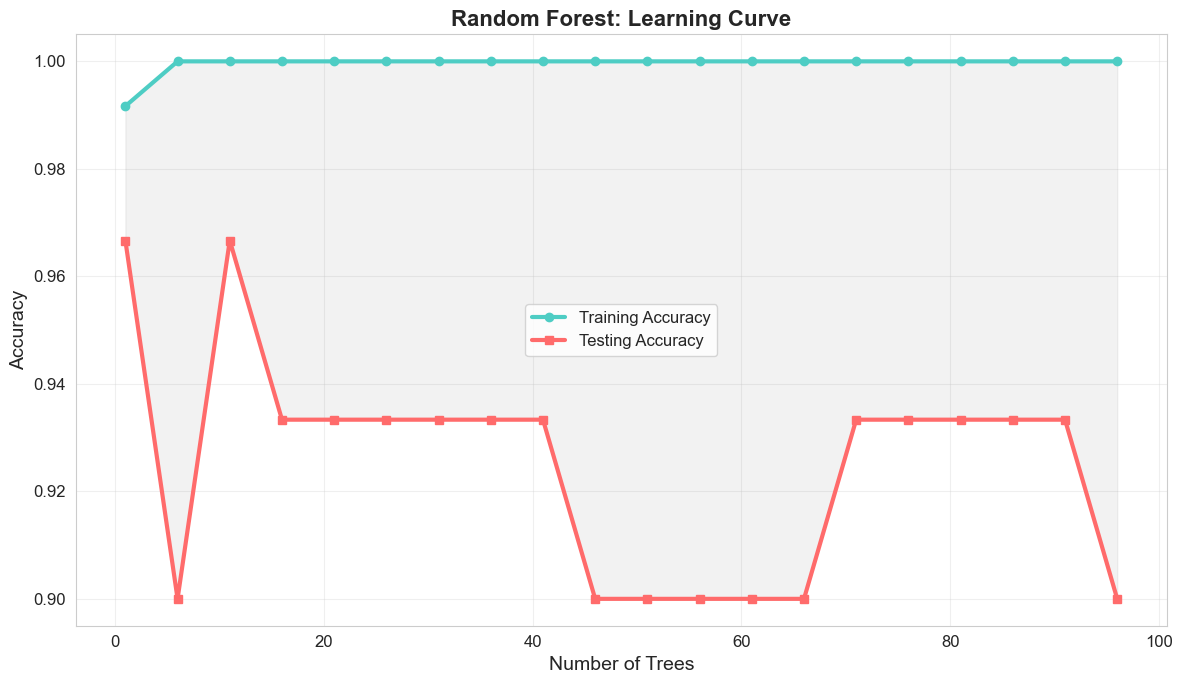

Optimal number of trees: 1 (Test Accuracy: 0.9667)


In [33]:
# Visualize training process for Random Forest (as an example)
print("\nVisualizing Random Forest training process...")

# Train Random Forest with different number of trees
n_estimators_range = range(1, 101, 5)
train_scores = []
test_scores = []

for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train_scaled, y_train)
    
    train_scores.append(rf.score(X_train_scaled, y_train))
    test_scores.append(rf.score(X_test_scaled, y_test))

# Plot learning curve
plt.figure(figsize=(12, 7))
plt.plot(n_estimators_range, train_scores, 'o-', color='#4ECDC4', linewidth=3, label='Training Accuracy')
plt.plot(n_estimators_range, test_scores, 's-', color='#FF6B6B', linewidth=3, label='Testing Accuracy')
plt.title('Random Forest: Learning Curve', fontsize=16, fontweight='bold')
plt.xlabel('Number of Trees', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.fill_between(n_estimators_range, train_scores, test_scores, alpha=0.1, color='gray')
plt.tight_layout()
plt.show()

# Find optimal number of trees
optimal_n = n_estimators_range[np.argmax(test_scores)]
print(f"Optimal number of trees: {optimal_n} (Test Accuracy: {max(test_scores):.4f})")

### 6.4 Feature Importance Analysis

In [35]:
# Get the best model (Random Forest based on our results)
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']

print(f"\nBest model: {best_model_name}")

# Feature importance for tree-based models
if hasattr(best_model, 'feature_importances_'):
    feature_importance = best_model.feature_importances_
    
    # Create DataFrame for feature importance
    importance_df = pd.DataFrame({
        'Feature': iris.feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importance:")
    display(importance_df)
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    bars = plt.barh(importance_df['Feature'], importance_df['Importance'], 
                    color='#4ECDC4', edgecolor='black')
    plt.title(f'Feature Importance - {best_model_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Importance', fontsize=14)
    plt.ylabel('Feature', fontsize=14)
    plt.grid(True, alpha=0.3, axis='x')
    
    # Add value labels on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2.,
                f'{width:.3f}', ha='left', va='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# For non-tree based models, we can use coefficients (e.g., Logistic Regression)
elif hasattr(best_model, 'coef_'):
    coefficients = best_model.coef_
    
    # Create DataFrame for coefficients
    coef_df = pd.DataFrame(coefficients, columns=iris.feature_names, 
                          index=[f'Class {name}' for name in iris.target_names])
    
    print("\nModel Coefficients:")
    display(coef_df)
    
    # Plot coefficients
    plt.figure(figsize=(10, 6))
    x = np.arange(len(iris.feature_names))
    width = 0.25
    
    for i in range(len(iris.target_names)):
        plt.bar(x + i*width - width, coefficients[i], width, 
                label=f'Class {iris.target_names[i]}', 
                edgecolor='black')
    
    plt.title(f'Model Coefficients - {best_model_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Feature', fontsize=14)
    plt.ylabel('Coefficient Value', fontsize=14)
    plt.xticks(x, iris.feature_names)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


Best model: Support Vector Machine


# 7 Model Deployment Preparation 

In [36]:
print("="*60)
print("MODEL DEPLOYMENT PREPARATION")
print("="*60)

# Select the best model for deployment
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']

print(f"Selected model for deployment: {best_model_name}")
print(f"Model accuracy on test set: {results[best_model_name]['accuracy']:.4f}")

# Create a function to make predictions
def predict_iris(features, model=best_model, scaler=scaler):
    """
    Predict iris species from input features.
    
    Parameters:
    features (list or array): List of 4 feature values [sepal_length, sepal_width, 
                             petal_length, petal_width]
    model: Trained model for prediction
    scaler: Fitted scaler for feature standardization
    
    Returns:
    dict: Prediction results including species name, class index, and probabilities
    """
    # Convert to numpy array and reshape
    features_array = np.array(features).reshape(1, -1)
    
    # Standardize features
    features_scaled = scaler.transform(features_array)
    
    # Make prediction
    prediction = model.predict(features_scaled)[0]
    species_name = iris.target_names[prediction]
    
    # Get prediction probabilities if available
    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(features_scaled)[0]
        prob_dict = {iris.target_names[i]: float(prob) for i, prob in enumerate(probabilities)}
    else:
        prob_dict = None
    
    return {
        'species_index': int(prediction),
        'species_name': species_name,
        'probabilities': prob_dict
    }

# Test the prediction function
test_samples = [
    [5.1, 3.5, 1.4, 0.2],  # Expected: setosa
    [6.0, 2.9, 4.5, 1.5],  # Expected: versicolor
    [6.7, 3.0, 5.2, 2.3]   # Expected: virginica
]

print("\nTesting prediction function with sample inputs:")
for i, sample in enumerate(test_samples):
    result = predict_iris(sample)
    expected_species = iris.target_names[i]
    print(f"\nSample {i+1}: {sample}")
    print(f"  Predicted: {result['species_name']} (Expected: {expected_species})")
    if result['probabilities']:
        print(f"  Probabilities: {result['probabilities']}")

# Save the model and scaler for deployment
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the model and scaler
joblib.dump(best_model, 'models/iris_classifier.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("\nModel and scaler saved successfully!")
print("  - Model: models/iris_classifier.pkl")
print("  - Scaler: models/scaler.pkl")

MODEL DEPLOYMENT PREPARATION
Selected model for deployment: Support Vector Machine
Model accuracy on test set: 0.9667

Testing prediction function with sample inputs:

Sample 1: [5.1, 3.5, 1.4, 0.2]
  Predicted: setosa (Expected: setosa)
  Probabilities: {'setosa': 0.9720988566091773, 'versicolor': 0.015973986085471913, 'virginica': 0.011927157305350993}

Sample 2: [6.0, 2.9, 4.5, 1.5]
  Predicted: versicolor (Expected: versicolor)
  Probabilities: {'setosa': 0.008012968362711785, 'versicolor': 0.9238410497887151, 'virginica': 0.06814598184857303}

Sample 3: [6.7, 3.0, 5.2, 2.3]
  Predicted: virginica (Expected: virginica)
  Probabilities: {'setosa': 0.010066957583467259, 'versicolor': 0.007280338378574165, 'virginica': 0.9826527040379586}

Model and scaler saved successfully!
  - Model: models/iris_classifier.pkl
  - Scaler: models/scaler.pkl


# 8. Streamlit Deployment Application
#### This is a streamlit application.
#### This notebook saves the app as a python file in the project directory. 

In [65]:
streamlit_code = '''
import streamlit as st
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Set page configuration
st.set_page_config(
    page_title="Iris Flower Classifier",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Load model and scaler
@st.cache_resource
def load_model():
    model = joblib.load('models/iris_classifier.pkl')
    scaler = joblib.load('models/scaler.pkl')
    iris = load_iris()
    return model, scaler, iris

model, scaler, iris = load_model()

# Initialize session state for sliders
defaults = [5.8, 3.0, 4.0, 1.2]
slider_keys = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for k, v in zip(slider_keys, defaults):
    if k not in st.session_state:
        st.session_state[k] = v

# Title and description
st.title("🌸 Iris Flower Classification App")
st.markdown("Adjust the sliders to input flower measurements and see the prediction!")

# Sidebar sliders
st.sidebar.header("Input Features")
sepal_length = st.sidebar.slider("Sepal Length (cm)", 4.0, 8.0, key='sepal_length')
sepal_width = st.sidebar.slider("Sepal Width (cm)", 2.0, 4.5, key='sepal_width')
petal_length = st.sidebar.slider("Petal Length (cm)", 1.0, 7.0, key='petal_length')
petal_width = st.sidebar.slider("Petal Width (cm)", 0.1, 2.5, key='petal_width')

# Prepare feature vector
input_features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
input_scaled = scaler.transform(input_features)

# Prediction
prediction = model.predict(input_scaled)[0]
species_name = iris.target_names[prediction]
probabilities = model.predict_proba(input_scaled)[0] if hasattr(model, 'predict_proba') else None

# Display results
col1, col2 = st.columns([1,2])
with col1:
    st.subheader("Prediction Result")
    color_map = {'setosa': '#FF6B6B','versicolor': '#4ECDC4','virginica': '#45B7D1'}
    st.markdown(f"<div style='background-color:{color_map[species_name]}; padding: 20px; border-radius: 10px; text-align:center;'><h2 style='color:white;'>{species_name.upper()}</h2></div>", unsafe_allow_html=True)

    if probabilities is not None:
        st.subheader("Prediction Confidence")
        for s, p in zip(iris.target_names, probabilities):
            st.write(f"**{s.capitalize()}**: {p*100:.1f}%")
            st.progress(p)

with col2:
    st.subheader("Your Input Measurements")
    feature_names = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']
    feature_values = input_features[0]
    bar_colors = ['#96CEB4' if 'Sepal' in name else color_map[species_name] for name in feature_names]
    fig, ax = plt.subplots(figsize=(8,5))
    bars = ax.bar(feature_names, feature_values, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.set_ylabel("cm")
    ax.set_ylim(0, max(feature_values)*1.2)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f"{bar.get_height():.1f}", ha='center')
    plt.tight_layout()
    st.pyplot(fig)

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

st.title("Iris Feature Importance Demo")

# Load Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Train a RandomForest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Display Feature Importance
st.subheader("Feature Importance")
if hasattr(model, 'feature_importances_'):
    fi_df = pd.DataFrame({
        'Feature': iris.feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=True)  # ascending=True for horizontal bar

    # Plot
    fig, ax = plt.subplots(figsize=(6,4))
    ax.barh(fi_df['Feature'], fi_df['Importance'], color='#4ECDC4')
    ax.set_xlabel("Importance")
    ax.set_title("Random Forest Feature Importance")
    st.pyplot(fig)
else:
    st.write("Model does not have feature_importances_ attribute.")



from PIL import Image

st.title("Iris Flowers")

# Load an image from file
image = Image.open("iris_flowers.png")  # replace with your image path

# Display the image
st.image(image, caption="Here is the image", width=1000)






# iris_info_app.py
import streamlit as st
from sklearn.datasets import load_iris
import pandas as pd
from PIL import Image
import requests
from io import BytesIO

st.set_page_config(page_title="Iris Flower Information", layout="wide")
st.title("🌸 Iris Flower Information Viewer")

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Target'] = iris.target
target_mapping = {i: name for i, name in enumerate(iris.target_names)}

# Map target numbers to names
df['Target Name'] = df['Target'].map(target_mapping)

# --- Expander: Dataset Overview ---
with st.expander("📊 Dataset Overview"):
    st.dataframe(df)
    st.write("Feature names:", iris.feature_names)
    st.write("Target classes:", iris.target_names)

# --- Expander: Feature Description ---
feature_desc = {
    "sepal length (cm)": "Length of the sepal in centimeters",
    "sepal width (cm)": "Width of the sepal in centimeters",
    "petal length (cm)": "Length of the petal in centimeters",
    "petal width (cm)": "Width of the petal in centimeters"
}

with st.expander("🌿 Feature Description"):
    for feature, desc in feature_desc.items():
        st.write(f"**{feature}**: {desc}")

# --- Expander: Flower Images ---
from PIL import Image

st.title("Iris Flowers")

# Load an image from file
image = Image.open("iris_flowers.png")  # replace with your image path

# Display the image
st.image(image, caption="Here is the image", width=1000)




'''

# Save the file
with open('iris_app.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_code)

print("Streamlit app saved successfully as 'iris_app.py'!")
print("Run with: streamlit run iris_app.py")

Streamlit app saved successfully as 'iris_app.py'!
Run with: streamlit run iris_app.py


# 9 Final Summary and Instruction

In [45]:
print("="*80)
print("PROJECT COMPLETION SUMMARY")
print("="*80)

print("\n✅ COMPLETED TASKS:")
print("-"*40)
print("1. ✅ Loaded the Iris dataset")
print("2. ✅ Performed comprehensive EDA with visualizations")
print("3. ✅ Implemented the complete ML pipeline")
print("4. ✅ Trained and evaluated multiple classification models")
print("5. ✅ Visualized training process and model evaluation")
print("6. ✅ Prepared model for deployment and created Streamlit app")

print("\n📊 MODEL PERFORMANCE SUMMARY:")
print("-"*40)
print(f"Best model: {comparison_df.iloc[0]['Model']}")
print(f"Test accuracy: {comparison_df.iloc[0]['Accuracy']:.4f}")
print(f"F1-Score: {comparison_df.iloc[0]['F1-Score']:.4f}")

print("\n🚀 DEPLOYMENT INSTRUCTIONS:")
print("-"*40)
print("1. First, ensure you have Streamlit installed:")
print("   pip install streamlit")
print("\n2. Run the Streamlit app with:")
print("   streamlit run iris_app.py")
print("\n3. Open your browser and navigate to the URL shown in the terminal")
print("   (typically http://localhost:8501)")

print("\n📁 FILES CREATED:")
print("-"*40)
print("1. This notebook with complete ML pipeline")
print("2. iris_app.py - Streamlit deployment application")
print("3. models/iris_classifier.pkl - Saved model")
print("4. models/scaler.pkl - Saved feature scaler")

print("\n🎯 NEXT STEPS:")
print("-"*40)
print("1. Run the Streamlit app to test the deployment")
print("2. Consider hyperparameter tuning for even better performance")
print("3. Explore other classification algorithms")
print("4. Deploy to cloud platforms (Streamlit Cloud, Heroku, etc.)")

print("\n" + "="*80)
print("PROJECT COMPLETE - READY FOR DEPLOYMENT!")
print("="*80)

PROJECT COMPLETION SUMMARY

✅ COMPLETED TASKS:
----------------------------------------
1. ✅ Loaded the Iris dataset
2. ✅ Performed comprehensive EDA with visualizations
3. ✅ Implemented the complete ML pipeline
4. ✅ Trained and evaluated multiple classification models
5. ✅ Visualized training process and model evaluation
6. ✅ Prepared model for deployment and created Streamlit app

📊 MODEL PERFORMANCE SUMMARY:
----------------------------------------
Best model: Support Vector Machine
Test accuracy: 0.9667
F1-Score: 0.9666

🚀 DEPLOYMENT INSTRUCTIONS:
----------------------------------------
1. First, ensure you have Streamlit installed:
   pip install streamlit

2. Run the Streamlit app with:
   streamlit run iris_app.py

3. Open your browser and navigate to the URL shown in the terminal
   (typically http://localhost:8501)

📁 FILES CREATED:
----------------------------------------
1. This notebook with complete ML pipeline
2. iris_app.py - Streamlit deployment application
3. models/i